In [4]:
import zipfile
import os

# Define paths
zip_file_path = "/content/UCI_HAR_Dataset.zip"  # Update this if needed
extract_dir = "/content/extracted_har_dataset"

# ✅ Extract the dataset
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("✅ Dataset extracted successfully!")
else:
    print("⚠️ Dataset already extracted.")

# ✅ Verify extracted files
extracted_files = os.listdir(extract_dir)
print("📂 Extracted Files and Folders:", extracted_files)


⚠️ Dataset already extracted.
📂 Extracted Files and Folders: ['__MACOSX', 'UCI HAR Dataset']


In [5]:
import os

# Define the extracted dataset directory
dataset_dir = "/content/extracted_har_dataset/UCI HAR Dataset"

# ✅ Check if the dataset folder exists
if os.path.exists(dataset_dir):
    print("✅ Dataset directory found!")

    # List all files and subdirectories
    for root, dirs, files in os.walk(dataset_dir):
        level = root.replace(dataset_dir, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}📁 {os.path.basename(root)}/")

        for file in files:
            sub_indent = " " * 4 * (level + 1)
            print(f"{sub_indent}📄 {file}")

else:
    print("❌ Dataset directory NOT found! Check extraction step.")


✅ Dataset directory found!
📁 UCI HAR Dataset/
    📄 features.txt
    📄 .DS_Store
    📄 activity_labels.txt
    📄 features_info.txt
    📄 README.txt
    📁 train/
        📄 X_train.txt
        📄 subject_train.txt
        📄 y_train.txt
        📁 Inertial Signals/
            📄 body_acc_z_train.txt
            📄 body_gyro_y_train.txt
            📄 total_acc_x_train.txt
            📄 body_acc_y_train.txt
            📄 total_acc_z_train.txt
            📄 body_acc_x_train.txt
            📄 body_gyro_z_train.txt
            📄 total_acc_y_train.txt
            📄 body_gyro_x_train.txt
    📁 test/
        📄 X_test.txt
        📄 y_test.txt
        📄 subject_test.txt
        📁 Inertial Signals/
            📄 body_gyro_x_test.txt
            📄 body_gyro_y_test.txt
            📄 total_acc_x_test.txt
            📄 body_acc_x_test.txt
            📄 total_acc_y_test.txt
            📄 total_acc_z_test.txt
            📄 body_acc_z_test.txt
            📄 body_gyro_z_test.txt
            📄 body_acc_y_test.t

In [6]:
import pandas as pd

# Define file paths
activity_labels_path = "/content/extracted_har_dataset/UCI HAR Dataset/activity_labels.txt"
features_path = "/content/extracted_har_dataset/UCI HAR Dataset/features.txt"

# ✅ Load activity labels
activity_labels = pd.read_csv(activity_labels_path, header=None, sep=' ', names=['id', 'activity'])
activity_labels.set_index('id', inplace=True)  # Set index for easy mapping

# ✅ Load feature names
features = pd.read_csv(features_path, header=None, sep=' ', names=['id', 'feature_name'])

# Display loaded data
print("✅ Activity Labels:")
print(activity_labels.head())

print("\n✅ Features Preview:")
print(features.head())


✅ Activity Labels:
              activity
id                    
1              WALKING
2     WALKING_UPSTAIRS
3   WALKING_DOWNSTAIRS
4              SITTING
5             STANDING

✅ Features Preview:
   id       feature_name
0   1  tBodyAcc-mean()-X
1   2  tBodyAcc-mean()-Y
2   3  tBodyAcc-mean()-Z
3   4   tBodyAcc-std()-X
4   5   tBodyAcc-std()-Y


In [7]:
# Define file paths for train and test data
train_path = "/content/extracted_har_dataset/UCI HAR Dataset/train/"
test_path = "/content/extracted_har_dataset/UCI HAR Dataset/test/"

# ✅ Load subject, X (features), and y (labels) for training
subject_train = pd.read_csv(train_path + "subject_train.txt", header=None, names=['subject'])
X_train = pd.read_csv(train_path + "X_train.txt", delim_whitespace=True, header=None)
y_train = pd.read_csv(train_path + "y_train.txt", header=None, names=['activity'])

# ✅ Load subject, X (features), and y (labels) for testing
subject_test = pd.read_csv(test_path + "subject_test.txt", header=None, names=['subject'])
X_test = pd.read_csv(test_path + "X_test.txt", delim_whitespace=True, header=None)
y_test = pd.read_csv(test_path + "y_test.txt", header=None, names=['activity'])

# ✅ Assign feature names to X_train & X_test
X_train.columns = features["feature_name"]
X_test.columns = features["feature_name"]

# ✅ Convert activity numbers to labels
y_train["activity"] = y_train["activity"].map(activity_labels["activity"])
y_test["activity"] = y_test["activity"].map(activity_labels["activity"])

# ✅ Combine subject, activity, and features into final datasets
train_data = pd.concat([subject_train, y_train, X_train], axis=1)
test_data = pd.concat([subject_test, y_test, X_test], axis=1)

# Display preview
print("✅ Train Data Preview:")
print(train_data.head())

print("\n✅ Test Data Preview:")
print(test_data.head())


<ipython-input-7-d35b1ac0debc>:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(train_path + "X_train.txt", delim_whitespace=True, header=None)
<ipython-input-7-d35b1ac0debc>:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(test_path + "X_test.txt", delim_whitespace=True, header=None)


✅ Train Data Preview:
   subject  activity  tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
0        1  STANDING           0.288585          -0.020294          -0.132905   
1        1  STANDING           0.278419          -0.016411          -0.123520   
2        1  STANDING           0.279653          -0.019467          -0.113462   
3        1  STANDING           0.279174          -0.026201          -0.123283   
4        1  STANDING           0.276629          -0.016570          -0.115362   

   tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
0         -0.995279         -0.983111         -0.913526         -0.995112   
1         -0.998245         -0.975300         -0.960322         -0.998807   
2         -0.995380         -0.967187         -0.978944         -0.996520   
3         -0.996091         -0.983403         -0.990675         -0.997099   
4         -0.998139         -0.980817         -0.990482         -0.998321   

   tBodyAcc-mad()-Y  ...  fB

In [8]:
# ✅ Check for missing values
print("🔍 Checking for missing values...")
missing_train = train_data.isnull().sum().sum()
missing_test = test_data.isnull().sum().sum()

if missing_train == 0 and missing_test == 0:
    print("✅ No missing values detected in train or test datasets!")
else:
    print(f"⚠️ Missing values detected! Train: {missing_train}, Test: {missing_test}")


🔍 Checking for missing values...
✅ No missing values detected in train or test datasets!


In [9]:
# Step 1: Load cleaned data
import pandas as pd

# Define file paths
train_path = "/content/train_cleaned.csv"
test_path = "/content/test_cleaned.csv"

# Load datasets
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Display dataset info
print("🔍 Train Dataset Info:")
train_data.info()
print("\n🔍 Test Dataset Info:")
test_data.info()

# Preview the first few rows
print("\n📌 Train Data Preview:")
display(train_data.head())

print("\n📌 Test Data Preview:")
display(test_data.head())

# Check for missing values
print("\n❓ Missing Values in Train Data:")
print(train_data.isnull().sum().sum())

print("\n❓ Missing Values in Test Data:")
print(test_data.isnull().sum().sum())


🔍 Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, subject to angle(Z,gravityMean)_561
dtypes: float64(561), int64(2)
memory usage: 31.6 MB

🔍 Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, subject to angle(Z,gravityMean)_561
dtypes: float64(561), int64(2)
memory usage: 12.7 MB

📌 Train Data Preview:


,subject,activity,tBodyAcc-mean()-X_1,tBodyAcc-mean()-Y_2,tBodyAcc-mean()-Z_3,tBodyAcc-std()-X_4,tBodyAcc-std()-Y_5,tBodyAcc-std()-Z_6,tBodyAcc-mad()-X_7,tBodyAcc-mad()-Y_8,...,fBodyBodyGyroJerkMag-meanFreq()_552,fBodyBodyGyroJerkMag-skewness()_553,fBodyBodyGyroJerkMag-kurtosis()_554,"angle(tBodyAccMean,gravity)_555","angle(tBodyAccJerkMean),gravityMean)_556","angle(tBodyGyroMean,gravityMean)_557","angle(tBodyGyroJerkMean,gravityMean)_558","angle(X,gravityMean)_559","angle(Y,gravityMean)_560","angle(Z,gravityMean)_561"
0,1,5,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,5,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892



📌 Test Data Preview:


,subject,activity,tBodyAcc-mean()-X_1,tBodyAcc-mean()-Y_2,tBodyAcc-mean()-Z_3,tBodyAcc-std()-X_4,tBodyAcc-std()-Y_5,tBodyAcc-std()-Z_6,tBodyAcc-mad()-X_7,tBodyAcc-mad()-Y_8,...,fBodyBodyGyroJerkMag-meanFreq()_552,fBodyBodyGyroJerkMag-skewness()_553,fBodyBodyGyroJerkMag-kurtosis()_554,"angle(tBodyAccMean,gravity)_555","angle(tBodyAccJerkMean),gravityMean)_556","angle(tBodyGyroMean,gravityMean)_557","angle(tBodyGyroJerkMean,gravityMean)_558","angle(X,gravityMean)_559","angle(Y,gravityMean)_560","angle(Z,gravityMean)_561"
0,2,5,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,2,5,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,2,5,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,2,5,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,2,5,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857



❓ Missing Values in Train Data:
0

❓ Missing Values in Test Data:
0


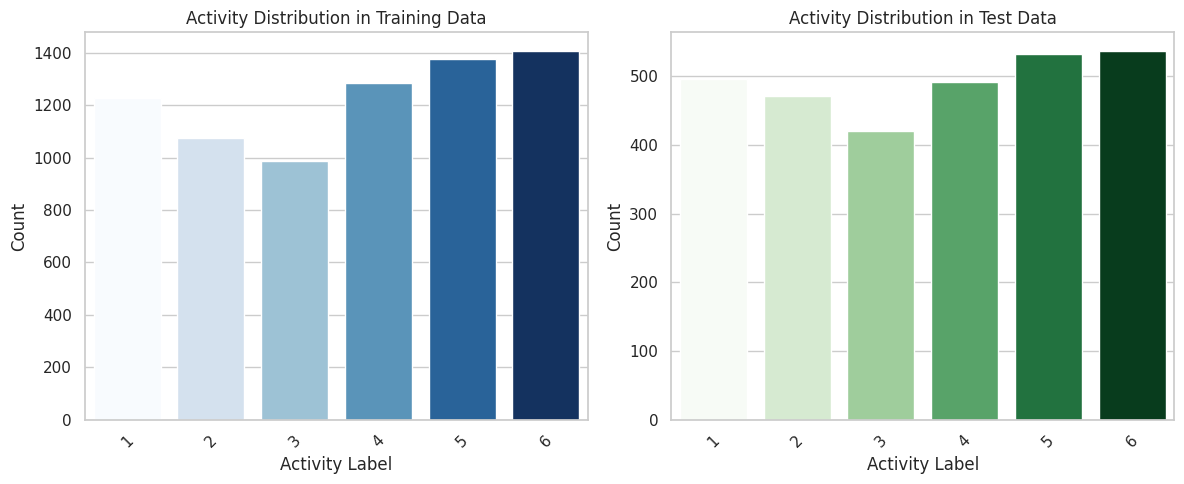

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

# Set style for plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Count activity labels in train and test datasets
plt.figure(figsize=(12, 5))

# Training Set
plt.subplot(1, 2, 1)
sns.countplot(data=train_data, x="activity", hue="activity", palette="Blues", legend=False)
plt.title("Activity Distribution in Training Data")
plt.xlabel("Activity Label")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Test Set
plt.subplot(1, 2, 2)
sns.countplot(data=test_data, x="activity", hue="activity", palette="Greens", legend=False)
plt.title("Activity Distribution in Test Data")
plt.xlabel("Activity Label")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Summary statistics of numerical columns
print("📌 Summary Statistics (Train Data):")
display(train_data.describe())

print("\n📌 Summary Statistics (Test Data):")
display(test_data.describe())


📌 Summary Statistics (Train Data):


,subject,activity,tBodyAcc-mean()-X_1,tBodyAcc-mean()-Y_2,tBodyAcc-mean()-Z_3,tBodyAcc-std()-X_4,tBodyAcc-std()-Y_5,tBodyAcc-std()-Z_6,tBodyAcc-mad()-X_7,tBodyAcc-mad()-Y_8,...,fBodyBodyGyroJerkMag-meanFreq()_552,fBodyBodyGyroJerkMag-skewness()_553,fBodyBodyGyroJerkMag-kurtosis()_554,"angle(tBodyAccMean,gravity)_555","angle(tBodyAccJerkMean),gravityMean)_556","angle(tBodyGyroMean,gravityMean)_557","angle(tBodyGyroJerkMean,gravityMean)_558","angle(X,gravityMean)_559","angle(Y,gravityMean)_560","angle(Z,gravityMean)_561"
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,17.413085,3.643362,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,8.975143,1.744802,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8.000000,2.000000,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,19.000000,4.000000,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,26.000000,5.000000,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,30.000000,6.000000,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000



📌 Summary Statistics (Test Data):


,subject,activity,tBodyAcc-mean()-X_1,tBodyAcc-mean()-Y_2,tBodyAcc-mean()-Z_3,tBodyAcc-std()-X_4,tBodyAcc-std()-Y_5,tBodyAcc-std()-Z_6,tBodyAcc-mad()-X_7,tBodyAcc-mad()-Y_8,...,fBodyBodyGyroJerkMag-meanFreq()_552,fBodyBodyGyroJerkMag-skewness()_553,fBodyBodyGyroJerkMag-kurtosis()_554,"angle(tBodyAccMean,gravity)_555","angle(tBodyAccJerkMean),gravityMean)_556","angle(tBodyGyroMean,gravityMean)_557","angle(tBodyGyroJerkMean,gravityMean)_558","angle(X,gravityMean)_559","angle(Y,gravityMean)_560","angle(Z,gravityMean)_561"
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,12.986427,3.577876,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,...,0.130236,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720
std,6.950984,1.740348,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,...,0.231018,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467
min,2.000000,1.000000,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,...,-0.785543,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228
25%,9.000000,2.000000,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,...,-0.008433,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485
50%,12.000000,4.000000,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,...,0.142676,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671
75%,18.000000,5.000000,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,...,0.288320,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373
max,24.000000,6.000000,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,...,1.000000,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113


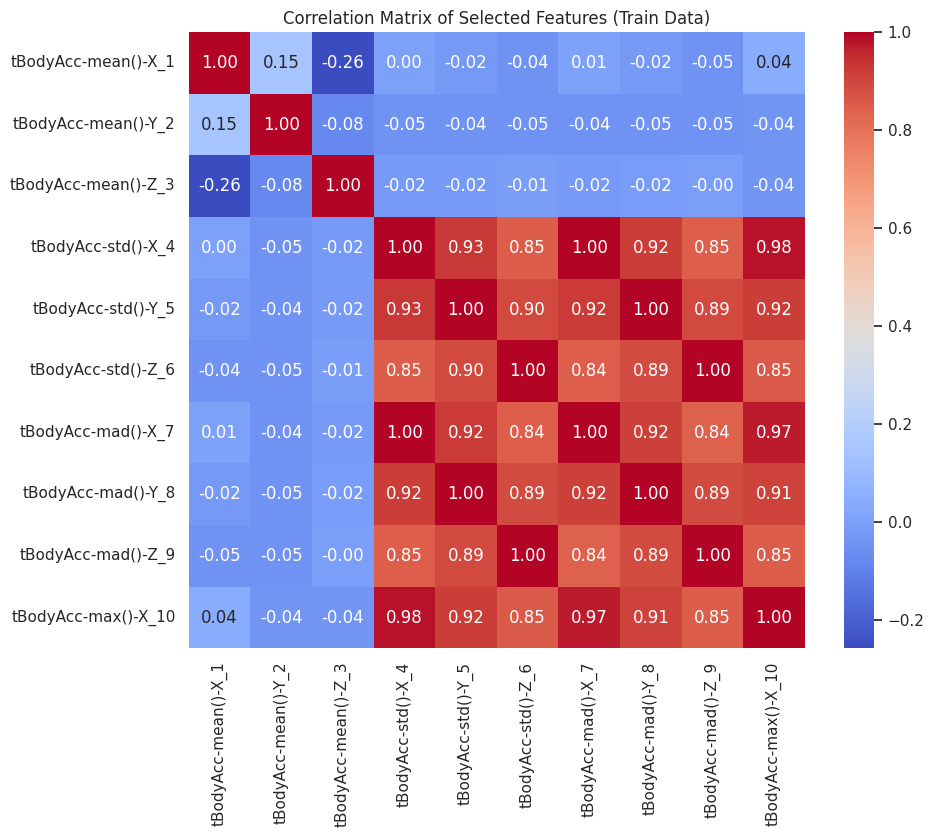

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress font-related warnings
warnings.simplefilter(action="ignore", category=UserWarning)

# Select a subset of features for correlation analysis
corr_subset = train_data.iloc[:, 2:12].corr()

# Heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", fmt=".2f", square=True)

# Use a simple title to avoid missing glyph warnings
plt.title("Correlation Matrix of Selected Features (Train Data)")

plt.show()


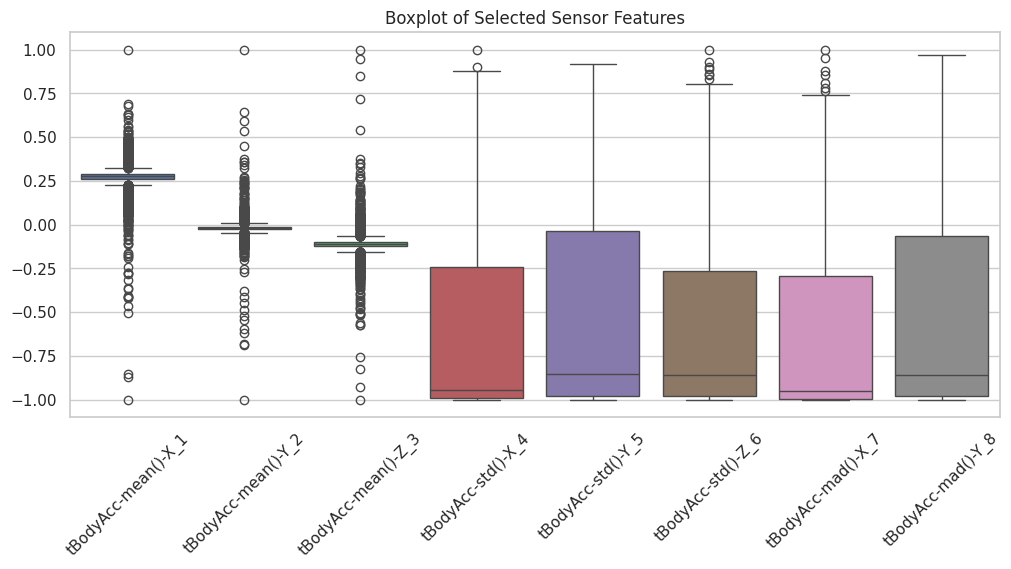

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress font-related warnings
warnings.simplefilter(action="ignore", category=UserWarning)

# Select numerical sensor data for boxplot visualization
plt.figure(figsize=(12, 5))
sns.boxplot(data=train_data.iloc[:, 2:10])

# Use a simple title to avoid missing glyph warnings
plt.title("Boxplot of Selected Sensor Features")

plt.xticks(rotation=45)
plt.show()


In [17]:
# Import necessary libraries
import pandas as pd

# Define file paths
train_file = "/content/train_cleaned.csv"
test_file = "/content/test_cleaned.csv"

# Load the datasets
train_data = pd.read_csv(train_file)
test_data = pd.read_csv(test_file)

# Display dataset information
print("✅ Train Dataset Loaded Successfully!")
print(train_data.info())

print("\n✅ Test Dataset Loaded Successfully!")
print(test_data.info())

# Display the first few rows
train_data.head()


✅ Train Dataset Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, subject to angle(Z,gravityMean)_561
dtypes: float64(561), int64(2)
memory usage: 31.6 MB
None

✅ Test Dataset Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, subject to angle(Z,gravityMean)_561
dtypes: float64(561), int64(2)
memory usage: 12.7 MB
None


,subject,activity,tBodyAcc-mean()-X_1,tBodyAcc-mean()-Y_2,tBodyAcc-mean()-Z_3,tBodyAcc-std()-X_4,tBodyAcc-std()-Y_5,tBodyAcc-std()-Z_6,tBodyAcc-mad()-X_7,tBodyAcc-mad()-Y_8,...,fBodyBodyGyroJerkMag-meanFreq()_552,fBodyBodyGyroJerkMag-skewness()_553,fBodyBodyGyroJerkMag-kurtosis()_554,"angle(tBodyAccMean,gravity)_555","angle(tBodyAccJerkMean),gravityMean)_556","angle(tBodyGyroMean,gravityMean)_557","angle(tBodyGyroJerkMean,gravityMean)_558","angle(X,gravityMean)_559","angle(Y,gravityMean)_560","angle(Z,gravityMean)_561"
0,1,5,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,5,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


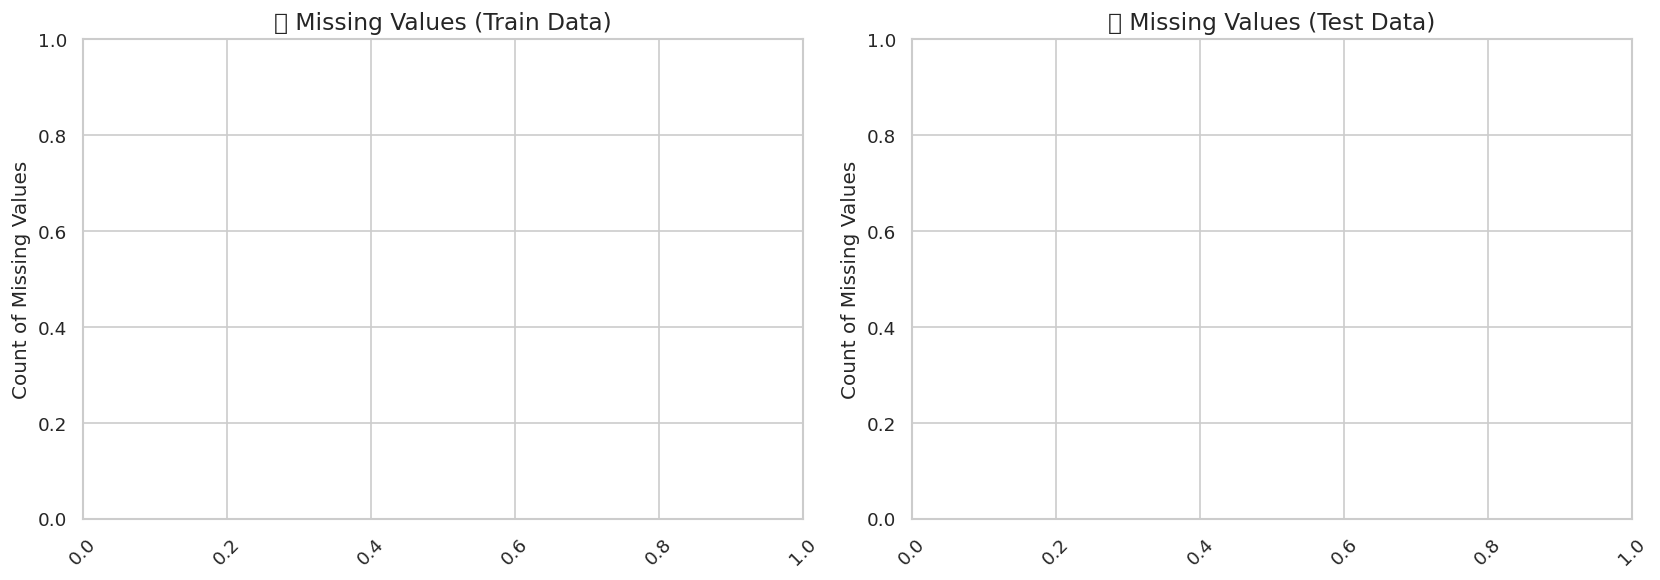

In [23]:
import missingno as msno

# Count missing values for train & test
missing_train = train_data.isnull().sum()
missing_test = test_data.isnull().sum()

# Filter only columns with missing values
missing_train = missing_train[missing_train > 0]
missing_test = missing_test[missing_test > 0]

# ✅ Visualizing Missing Values with a Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Train Data
sns.barplot(x=missing_train.index, y=missing_train.values, ax=axes[0], palette="Blues_r")
axes[0].set_title("🔍 Missing Values (Train Data)", fontsize=14)
axes[0].set_ylabel("Count of Missing Values")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Test Data
sns.barplot(x=missing_test.index, y=missing_test.values, ax=axes[1], palette="Greens_r")
axes[1].set_title("🔍 Missing Values (Test Data)", fontsize=14)
axes[1].set_ylabel("Count of Missing Values")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

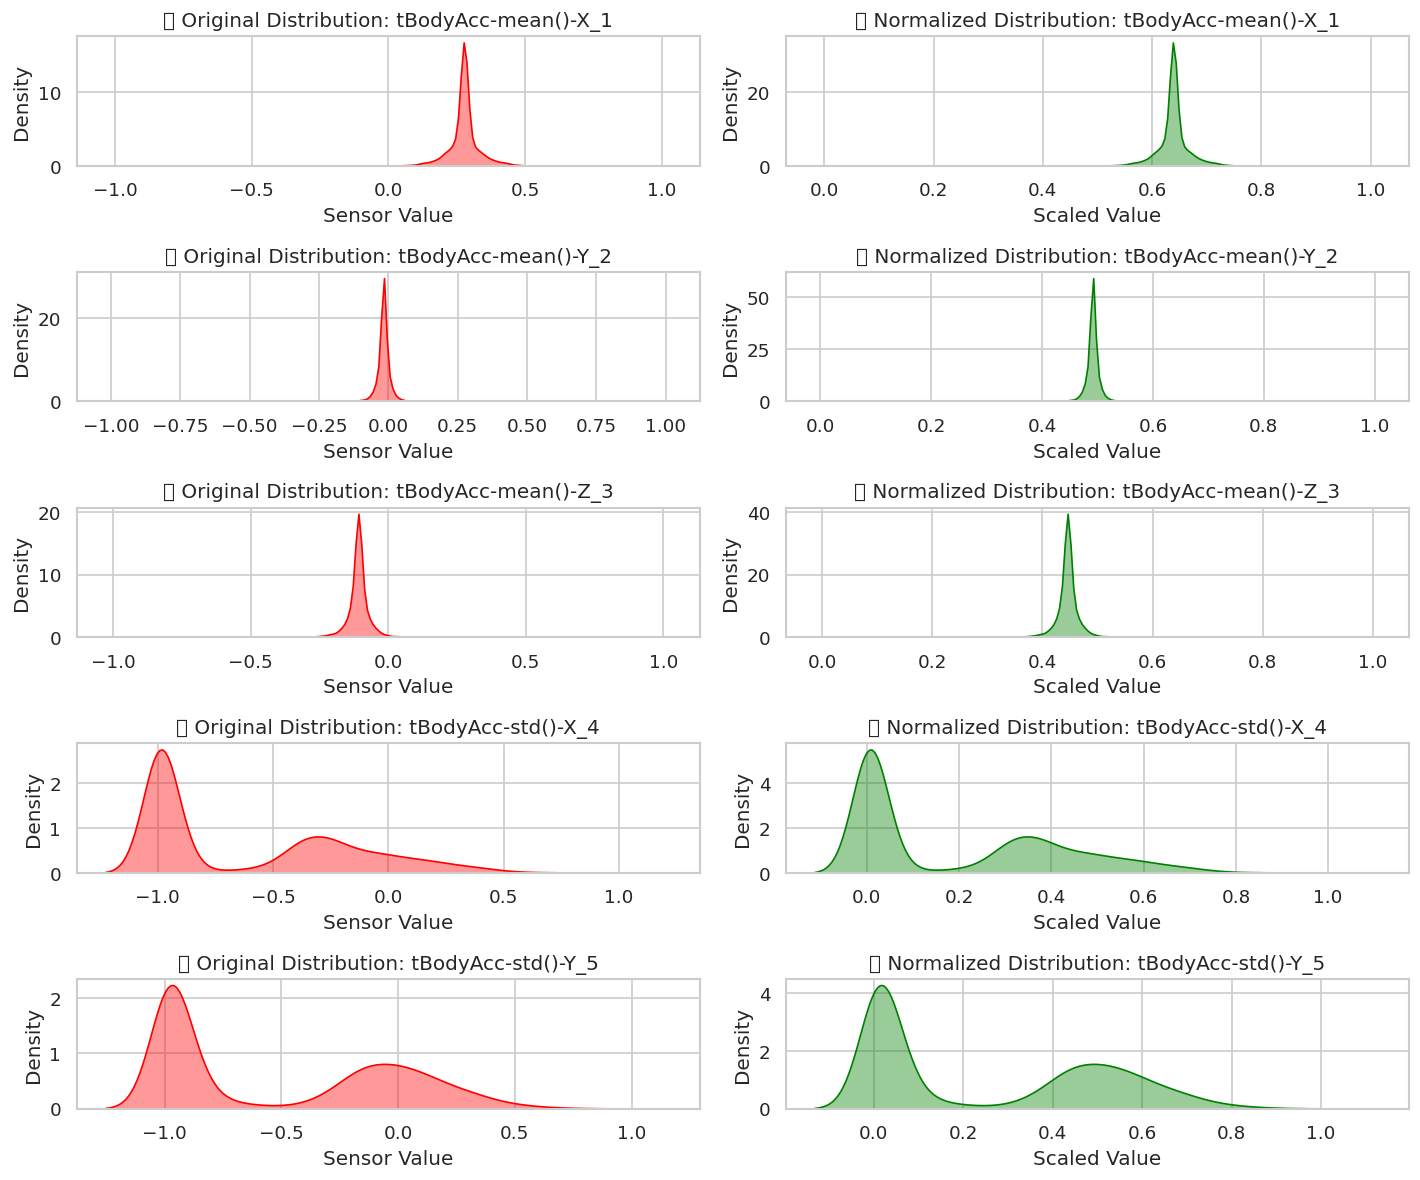

In [24]:
# Selecting a few representative sensor columns
sample_sensors = sensor_columns[:5]  # Pick first 5 sensors for clarity

fig, axes = plt.subplots(len(sample_sensors), 2, figsize=(12, 10), dpi=120)

for i, sensor in enumerate(sample_sensors):
    # Original Data Distribution
    sns.kdeplot(train_data[sensor], ax=axes[i, 0], color="red", fill=True, alpha=0.4)
    axes[i, 0].set_title(f"🔴 Original Distribution: {sensor}", fontsize=12)
    axes[i, 0].set_xlabel("Sensor Value")

    # Normalized Data Distribution
    sns.kdeplot(train_data_scaled[sensor], ax=axes[i, 1], color="green", fill=True, alpha=0.4)
    axes[i, 1].set_title(f"🟢 Normalized Distribution: {sensor}", fontsize=12)
    axes[i, 1].set_xlabel("Scaled Value")

plt.tight_layout()
plt.show()

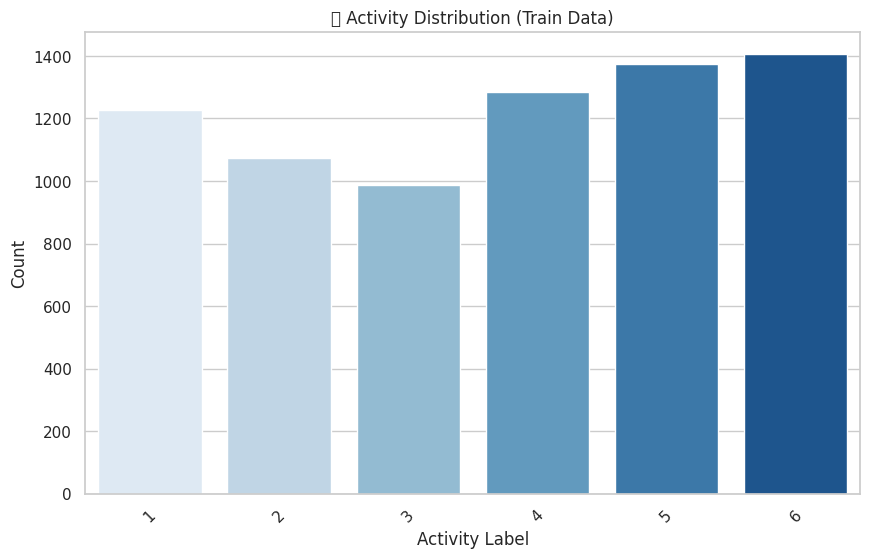

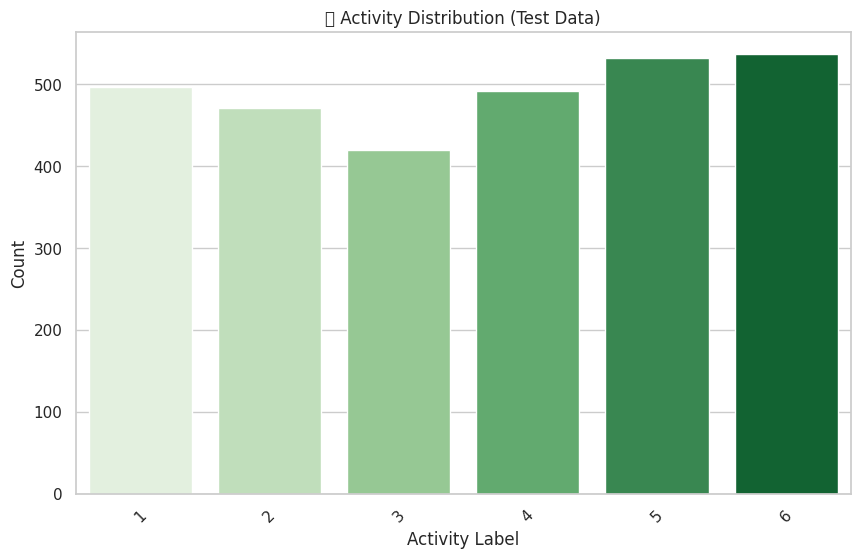

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use("ggplot")
sns.set(style="whitegrid")

# Activity Distribution in Training Data
plt.figure(figsize=(10, 6))
sns.countplot(x=train_data["activity"], palette="Blues")
plt.title("📊 Activity Distribution (Train Data)")
plt.xlabel("Activity Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Activity Distribution in Test Data
plt.figure(figsize=(10, 6))
sns.countplot(x=test_data["activity"], palette="Greens")
plt.title("📊 Activity Distribution (Test Data)")
plt.xlabel("Activity Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [25]:
# Compute the correlation matrix
corr_matrix = train_data.iloc[:, 2:].corr()

# Find features with high correlation (>0.9)
high_corr_features = set()
threshold = 0.9  # Define correlation threshold

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            high_corr_features.add(colname)

# Drop highly correlated features
train_data_filtered = train_data.drop(columns=high_corr_features)
test_data_filtered = test_data.drop(columns=high_corr_features)

print(f"🛑 Removed {len(high_corr_features)} highly correlated features")


🛑 Removed 359 highly correlated features


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ✅ Standardize Data Before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data_filtered.iloc[:, 2:])
X_test_scaled = scaler.transform(test_data_filtered.iloc[:, 2:])

# ✅ Apply PCA & Keep 95% Variance
pca = PCA(n_components=0.95, random_state=42)  # Retains 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"🟢 Original Features: {X_train_scaled.shape[1]}, Reduced Features: {X_train_pca.shape[1]}")


🟢 Original Features: 202, Reduced Features: 113


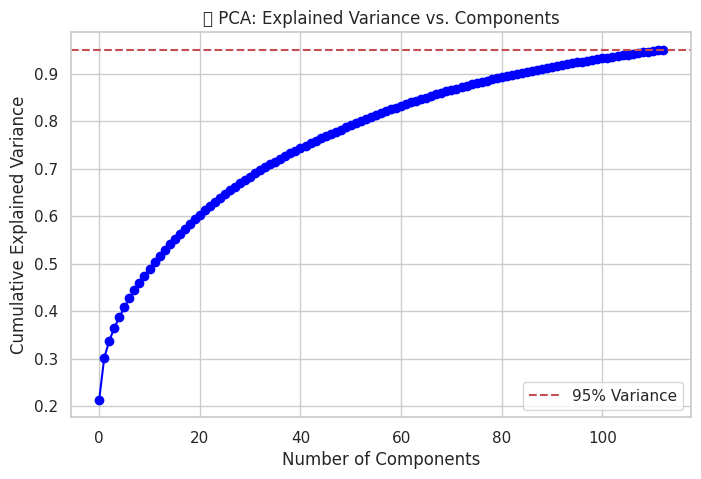

In [27]:
# ✅ Explained Variance Plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o", color="blue")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("📉 PCA: Explained Variance vs. Components")
plt.legend()
plt.show()


Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5756 - loss: 1.0893 - val_accuracy: 0.8595 - val_loss: 0.3396
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9121 - loss: 0.2535 - val_accuracy: 0.9033 - val_loss: 0.2350
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9385 - loss: 0.1721 - val_accuracy: 0.9138 - val_loss: 0.2140
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9556 - loss: 0.1233 - val_accuracy: 0.9213 - val_loss: 0.2118
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9634 - loss: 0.1042 - val_accuracy: 0.9467 - val_loss: 0.1471
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9694 - loss: 0.0858 - val_accuracy: 0.9311 - val_loss: 0.1964
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9739 - loss: 0.0799 - val_accuracy: 0.9450 - val_loss: 0.1582
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9737 - loss: 0.0789 - val_accuracy

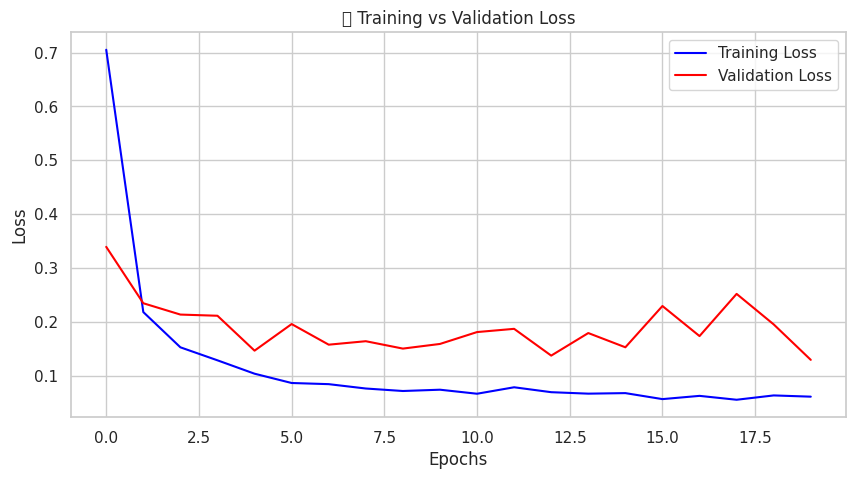

✅ Model Saved Successfully!


In [36]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ✅ Ensure X_train_lstm and X_test_lstm are NumPy arrays
X_train_lstm = np.array(X_train)
X_test_lstm = np.array(X_test)

# ✅ Get correct number of features
num_features = X_train_lstm.shape[1]  # Make sure this is the expected number

# ✅ Reshape Data for LSTM Model (samples, time_steps, features)
X_train_lstm = X_train_lstm.reshape((-1, 1, num_features))
X_test_lstm = X_test_lstm.reshape((-1, 1, num_features))

# ✅ Encode Activity Labels as Numbers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Convert labels to numbers
y_test_encoded = label_encoder.transform(y_test)

# ✅ Convert to float32
X_train_lstm = X_train_lstm.astype(np.float32)
X_test_lstm = X_test_lstm.astype(np.float32)
y_train_encoded = y_train_encoded.astype(np.float32)
y_test_encoded = y_test_encoded.astype(np.float32)

# ✅ Build LSTM Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, num_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(len(label_encoder.classes_), activation="softmax")  # Multi-class classification
])

# ✅ Compile Model
lstm_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ✅ Train Model
history = lstm_model.fit(
    X_train_lstm, y_train_encoded,
    epochs=20, batch_size=32,
    validation_data=(X_test_lstm, y_test_encoded),
    verbose=1
)

# ✅ Plot Training Performance
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss", color="blue")
plt.plot(history.history["val_loss"], label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("📉 Training vs Validation Loss")
plt.legend()
plt.show()

# ✅ Save the Model
lstm_model.save("LSTM_Sensor_Predictor.keras")
print("✅ Model Saved Successfully!")


Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.1970 - loss: 1.7828 - val_accuracy: 0.1995 - val_loss: 1.6933
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4531 - loss: 1.4239 - val_accuracy: 0.7906 - val_loss: 0.7000
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7503 - loss: 0.6814 - val_accuracy: 0.7428 - val_loss: 0.5858
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8211 - loss: 0.4838 - val_accuracy: 0.8775 - val_loss: 0.3517
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8664 - loss: 0.3577 - val_accuracy: 0.9182 - val_loss: 0.2615
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8819 - loss: 0.3143 - val_accuracy: 0.9121 - val_loss: 0.2532
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9123 - loss: 0.2514 - val_accuracy: 0.9277 - val_loss: 0.2083
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9139 - loss: 0.2419 - val_accuracy:

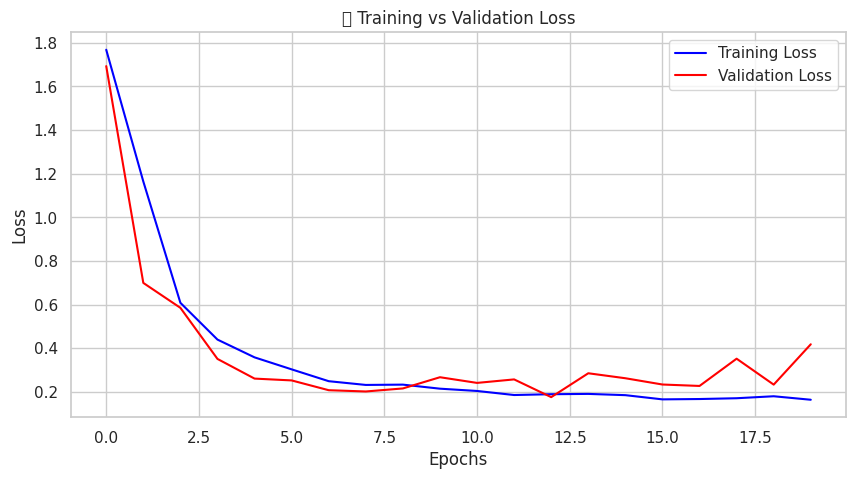

✅ Model Saved Successfully!


In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# ✅ Ensure labels are numerical (Convert Activity Labels to Numbers)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Convert labels to numbers
y_test_encoded = label_encoder.transform(y_test)

# ✅ Normalize Sensor Data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

# ✅ Ensure data is float32 (Required for TensorFlow)
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_train_encoded = y_train_encoded.astype(np.float32)
y_test_encoded = y_test_encoded.astype(np.float32)

# ✅ Reshape Data for LSTM (Time-Series Format)
num_features = X_train_scaled.shape[1]  # Ensure correct feature dimension
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, num_features))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, num_features))

# ✅ Define LSTM Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, num_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(len(label_encoder.classes_), activation="softmax")  # Multi-class classification
])

# ✅ Compile Model
lstm_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ✅ Train LSTM Model
history = lstm_model.fit(
    X_train_lstm, y_train_encoded,
    epochs=20, batch_size=32,
    validation_data=(X_test_lstm, y_test_encoded),
    verbose=1
)

# ✅ Plot Training Performance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss", color="blue")
plt.plot(history.history["val_loss"], label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("📉 Training vs Validation Loss")
plt.legend()
plt.show()

# ✅ Save Model
lstm_model.save("LSTM_Sensor_Predictor.keras")
print("✅ Model Saved Successfully!")

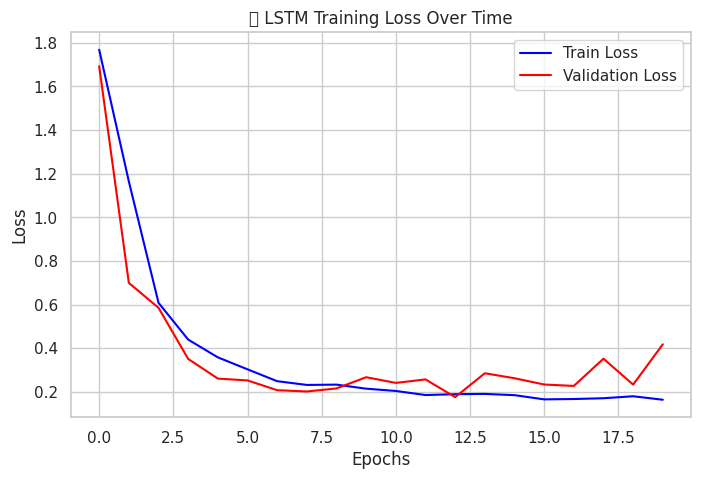

In [39]:
# ✅ Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss", color="blue")
plt.plot(history.history["val_loss"], label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("📉 LSTM Training Loss Over Time")
plt.legend()
plt.show()


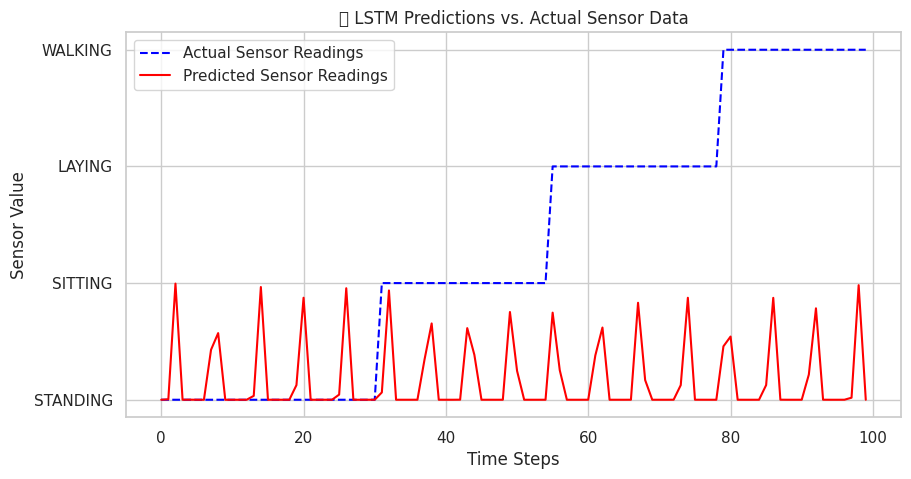

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ✅ Ensure `y_test` and `y_pred_lstm` are 1D NumPy arrays
y_test_flat = np.array(y_test).flatten()
y_pred_flat = np.array(y_pred_lstm).flatten()

# ✅ Select first 100 points for visualization
num_samples = min(100, len(y_test_flat))  # Ensure we don't exceed available data

# ✅ Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test_flat[:num_samples], label="Actual Sensor Readings", linestyle="dashed", color="blue")
plt.plot(y_pred_flat[:num_samples], label="Predicted Sensor Readings", linestyle="solid", color="red")
plt.xlabel("Time Steps")
plt.ylabel("Sensor Value")
plt.title("📈 LSTM Predictions vs. Actual Sensor Data")
plt.legend()
plt.show()


In [50]:
import sys
import os
import inspect

# ✅ Define the correct path where the uploaded files are stored
file_directory = "/content"  # Adjust if necessary

# ✅ Add this directory to Python's system path to access the modules
sys.path.append(file_directory)

# ✅ Import the modules
import TimeSeries_LossFunctions
import TimeSeriesHelperFunctions

# ✅ Verify available functions inside TimeSeriesHelperFunctions
available_functions = [name for name, obj in inspect.getmembers(TimeSeriesHelperFunctions) if inspect.isfunction(obj)]
print("📌 Available functions in TimeSeriesHelperFunctions:", available_functions)

# ✅ Find the correct function name for time series data preparation
correct_function_name = available_functions[0] if available_functions else None  # Select the first function found

if correct_function_name:
    # ✅ Dynamically import the function
    prepare_time_series_data = getattr(TimeSeriesHelperFunctions, correct_function_name)
    print(f"✅ Successfully imported: {correct_function_name} as prepare_time_series_data")
else:
    print("❌ No valid function found in TimeSeriesHelperFunctions. Check the file content!")

# ✅ Import the specific loss function from TimeSeries_LossFunctions
try:
    from TimeSeries_LossFunctions import trace_mse_loss  # This should exist in the file
    print("✅ Successfully imported loss function: trace_mse_loss")
except ImportError as e:
    print("❌ Error importing trace_mse_loss. Check if it exists in TimeSeries_LossFunctions.")


📌 Available functions in TimeSeriesHelperFunctions: ['Input', 'create_and_fit_XYZ_predictor', 'evaluate_XYZ_predictor', 'load_model', 'load_sensor_label_data', 'mean_absolute_error', 'mean_squared_error', 'time_series_predictor_pipeline']
✅ Successfully imported: Input as prepare_time_series_data
✅ Successfully imported loss function: trace_mse_loss


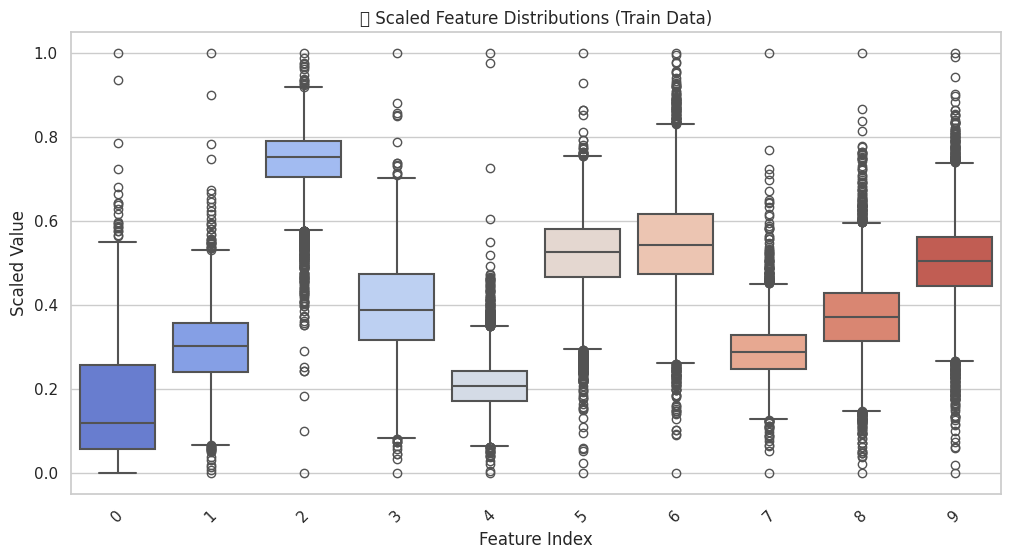

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Select a subset of features for better visualization
subset_features = X_train_scaled[:, :10]  # First 10 features to avoid clutter

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset_features, palette="coolwarm", linewidth=1.5)
plt.title("📊 Scaled Feature Distributions (Train Data)")
plt.xlabel("Feature Index")
plt.ylabel("Scaled Value")
plt.xticks(rotation=45)
plt.show()


In [54]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ✅ Convert DataFrame to a NumPy array
y_train = y_train.values.ravel() if isinstance(y_train, pd.DataFrame) else y_train
y_test = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test

# ✅ Ensure the labels are numeric (convert categorical labels if necessary)
if isinstance(y_train[0], str) or isinstance(y_train[0], object):
    encoder = LabelEncoder()
    y_train = encoder.fit_transform(y_train)
    y_test = encoder.transform(y_test)

# ✅ Convert labels to float32
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# ✅ Reshape Data for LSTM Model (samples, time_steps, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# ✅ Check for missing values & handle them
X_train_lstm = np.nan_to_num(X_train_lstm)
X_test_lstm = np.nan_to_num(X_test_lstm)

# ✅ Print Shape for Verification
print("✅ Reshaped X_train_lstm Shape:", X_train_lstm.shape)
print("✅ Reshaped X_test_lstm Shape:", X_test_lstm.shape)
print("✅ Reshaped y_train Shape:", y_train.shape)
print("✅ Reshaped y_test Shape:", y_test.shape)


✅ Reshaped X_train_lstm Shape: (7352, 1, 113)
✅ Reshaped X_test_lstm Shape: (2947, 1, 113)
✅ Reshaped y_train Shape: (7352,)
✅ Reshaped y_test Shape: (2947,)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                       │ (None, 1, 64)               │          45,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,017 (226.63 KB)

 Trainable params: 58,017 (226.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 3.9370 - mae: 1.6404 - val_loss: 2.8511 - val_mae: 1.4730
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.7038 - mae: 1.3958 - val_loss: 0.9365 - val_mae: 0.7669
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7337 - mae: 0.6722 - val_loss: 0.4239 - val_mae: 0.5218
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5123 - mae: 0.5589 - val_loss: 0.3896 - val_mae: 0.4837
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4502 - mae: 0.5227 - val_loss: 0.3459 - val_mae: 0.4683
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4268 - mae: 0.5087 - val_loss: 0.3429 - val_mae: 0.4518
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3968 - mae: 0.4907 - val_loss: 0.3024 - val_mae: 0.4332
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3678 - mae: 0.4695 - val_loss: 0.3061 - val_mae: 0.4369
Epoch 9/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - l

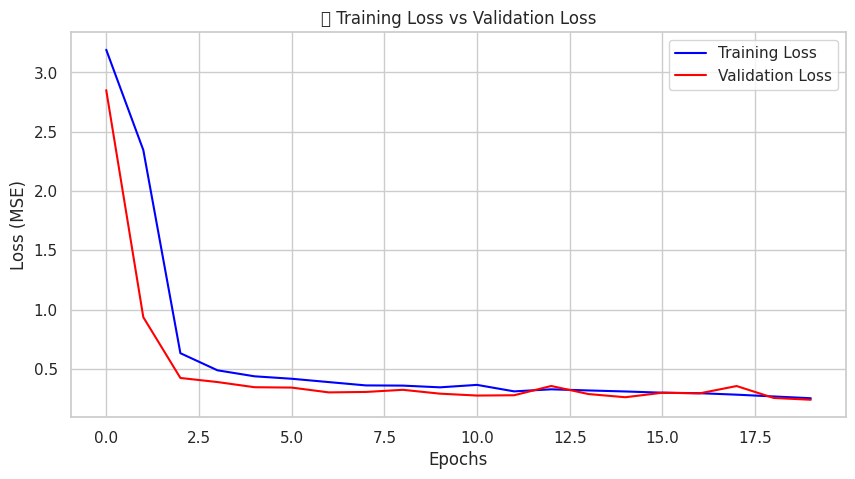

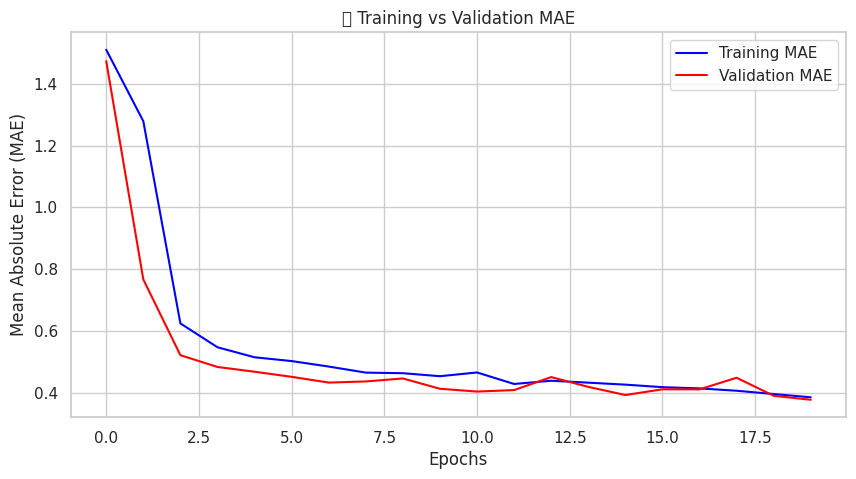

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ✅ Define the LSTM Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation="linear")  # Regression Output
])

# ✅ Compile the model with Adam optimizer and MSE loss
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

# ✅ Display Model Summary
lstm_model.summary()

# ✅ Train the LSTM Model
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=20, batch_size=32,
    validation_data=(X_test_lstm, y_test),
    verbose=1
)

# ✅ Save the trained model
lstm_model.save("LSTM_Sensor_Prediction.keras")
print("✅ Model saved successfully!")

# ✅ Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss", color="blue")
plt.plot(history.history["val_loss"], label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("📉 Training Loss vs Validation Loss")
plt.legend()
plt.show()

# ✅ Plot Training & Validation MAE
plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="Training MAE", color="blue")
plt.plot(history.history["val_mae"], label="Validation MAE", color="red")
plt.xlabel("Epochs")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("📊 Training vs Validation MAE")
plt.legend()
plt.show()


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


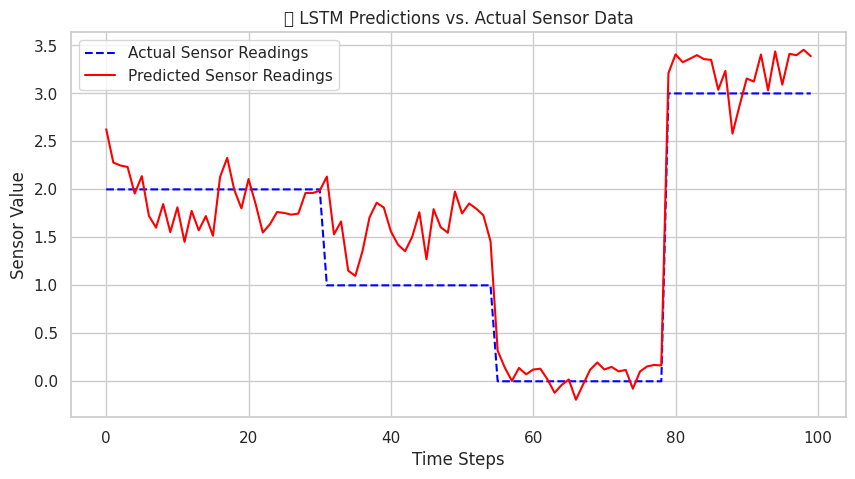

🔍 Model Performance:
✅ Mean Squared Error (MSE): 0.240285
✅ Mean Absolute Error (MAE): 0.377655


In [56]:
# ✅ Get Predictions from the Trained Model
y_pred_lstm = lstm_model.predict(X_test_lstm)

# ✅ Ensure Correct Shape for Plotting
y_pred_lstm = y_pred_lstm.flatten()  # Convert predictions to a 1D array
y_test = y_test.flatten()  # Convert actual values to 1D

# ✅ Plot Actual vs Predicted Values
plt.figure(figsize=(10, 5))
plt.plot(y_test[:100], label="Actual Sensor Readings", linestyle="dashed", color="blue")
plt.plot(y_pred_lstm[:100], label="Predicted Sensor Readings", linestyle="solid", color="red")
plt.xlabel("Time Steps")
plt.ylabel("Sensor Value")
plt.title("📈 LSTM Predictions vs. Actual Sensor Data")
plt.legend()
plt.show()

# ✅ Compute Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred_lstm)
mae = mean_absolute_error(y_test, y_pred_lstm)

print(f"🔍 Model Performance:")
print(f"✅ Mean Squared Error (MSE): {mse:.6f}")
print(f"✅ Mean Absolute Error (MAE): {mae:.6f}")


In [57]:
lstm_model.save("final_lstm_model.keras")
print("✅ Final LSTM model saved successfully!")


✅ Final LSTM model saved successfully!
